# 06 — Sales Forecasting

Provides **business-level temporal context** ("what's the expected near-term revenue direction?") rather than a customer-level prediction — a fifth analytical dimension alongside Segment / Churn / CLV / SHAP, consumed by Notebook 7 as background context for narration rather than as a per-customer signal.

> **Research perspective**: the notebook below *does* run a held-out evaluation (MAPE/RMSE on a trailing test window), so those numbers are available if you want to report forecast accuracy formally. If you decide not to lean on that evaluation for the paper, present this component as *contextual* forecasting only — don't claim forecasting accuracy you haven't actually validated for your final model/horizon.

In [1]:

from google.colab import drive
drive.mount('/content/drive')

!pip install -q duckdb pandas pyarrow scikit-learn xgboost lightgbm mlxtend shap prophet google-genai

from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/Colab Notebooks/Ecommerce-AI-Business-Intelligence")
DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FEATURES_DIR = PROCESSED_DIR / "features"
MODELS_DIR = PROCESSED_DIR / "models"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
WAREHOUSE_PATH = PROJECT_ROOT / "warehouse.duckdb"

for d in [PROCESSED_DIR, FEATURES_DIR, MODELS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)


Mounted at /content/drive
Project root: /content/drive/MyDrive/Colab Notebooks/Ecommerce-AI-Business-Intelligence


In [2]:

import pandas as pd
daily_sales = pd.read_parquet(FEATURES_DIR / "daily_sales.parquet")
daily_sales = daily_sales.set_index(pd.to_datetime(daily_sales["order_date"]))["revenue"].asfreq("D").fillna(0.0)
print(f"Series length: {len(daily_sales):,} days, {daily_sales.index.min().date()} to {daily_sales.index.max().date()}")


Series length: 730 days, 2016-09-04 to 2018-09-03


## Held-out evaluation

Last 60 days withheld as a test window.

In [3]:

TEST_DAYS = 60
FORECAST_HORIZON_DAYS = 30

train_ts, test_ts = daily_sales.iloc[:-TEST_DAYS], daily_sales.iloc[-TEST_DAYS:]

try:
    from prophet import Prophet
    HAVE_PROPHET = True
    print("Using Prophet")
except ImportError:
    HAVE_PROPHET = False
    print("prophet not available -> using a trend + day-of-week seasonal fallback forecaster.")

def fit_predict(train_series, horizon_days, have_prophet):
    if have_prophet:
        dfp = train_series.reset_index()
        dfp.columns = ["ds", "y"]
        m = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False)
        m.fit(dfp)
        future = m.make_future_dataframe(periods=horizon_days)
        fc = m.predict(future)
        return fc.set_index("ds")["yhat"].iloc[-horizon_days:]
    else:
        weekly_avg = train_series.groupby(train_series.index.dayofweek).mean()
        trend_level = train_series.rolling(28, min_periods=7).mean().iloc[-1]
        overall_mean = train_series.mean()
        seasonal_factor = weekly_avg / overall_mean
        future_index = pd.date_range(train_series.index[-1] + pd.Timedelta(days=1), periods=horizon_days, freq="D")
        return pd.Series([trend_level * seasonal_factor[d] for d in future_index.dayofweek], index=future_index)

test_preds = fit_predict(train_ts, TEST_DAYS, HAVE_PROPHET)

from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
nonzero_mask = test_ts.replace(0, pd.NA).dropna().index
mape = mean_absolute_percentage_error(test_ts.loc[nonzero_mask], test_preds.loc[nonzero_mask])
rmse = mean_squared_error(test_ts, test_preds) ** 0.5
print(f"Held-out evaluation: MAPE={mape:.4f}  RMSE={rmse:.2f}  (model: {'Prophet' if HAVE_PROPHET else 'fallback'})")


Using Prophet


Held-out evaluation: MAPE=5.2681  RMSE=14611.37  (model: Prophet)


## Forward forecast (for business-context use in Notebook 7)

Refit on the full series, then forecast forward beyond the last observed date.

In [4]:

future_preds = fit_predict(daily_sales, FORECAST_HORIZON_DAYS, HAVE_PROPHET)

forecast_series = pd.concat([
    daily_sales.rename("value").to_frame().assign(kind="actual"),
    future_preds.rename("value").to_frame().assign(kind="forecast"),
]).reset_index().rename(columns={"index": "date"})
forecast_series.to_parquet(MODELS_DIR / "forecast_series.parquet", index=False)

trailing_level = daily_sales.iloc[-FORECAST_HORIZON_DAYS:].mean()
forecast_level = future_preds.mean()
pct_change = (forecast_level - trailing_level) / trailing_level if trailing_level else float("nan")
direction = "increasing" if pct_change > 0.03 else ("decreasing" if pct_change < -0.03 else "flat")

import json
forecast_summary = {
    "horizon_days": FORECAST_HORIZON_DAYS,
    "as_of_date": str(daily_sales.index.max().date()),
    "trailing_daily_revenue": round(float(trailing_level), 2),
    "forecast_daily_revenue": round(float(forecast_level), 2),
    "pct_change": round(float(pct_change), 4),
    "direction": direction,
    "model": "Prophet" if HAVE_PROPHET else "trend_seasonal_fallback",
    "held_out_mape": round(float(mape), 4),
    "held_out_rmse": round(float(rmse), 2),
}
with open(MODELS_DIR / "forecast_summary.json", "w") as f:
    json.dump(forecast_summary, f, indent=2)

print(json.dumps(forecast_summary, indent=2))


{
  "horizon_days": 30,
  "as_of_date": "2018-09-03",
  "trailing_daily_revenue": 23274.27,
  "forecast_daily_revenue": 25730.17,
  "pct_change": 0.1055,
  "direction": "increasing",
  "model": "Prophet",
  "held_out_mape": 5.2681,
  "held_out_rmse": 14611.37
}


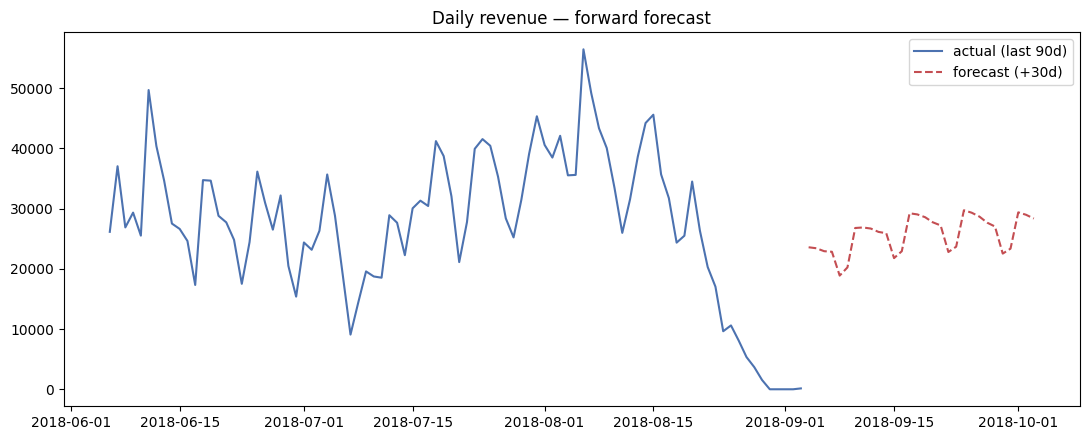

In [5]:

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(daily_sales.index[-90:], daily_sales.values[-90:], label="actual (last 90d)", color="#4C72B0")
ax.plot(future_preds.index, future_preds.values, label=f"forecast (+{FORECAST_HORIZON_DAYS}d)",
        color="#C44E52", linestyle="--")
ax.set_title("Daily revenue — forward forecast")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "forecast_forward.png", dpi=110)
plt.show()


---
### Outputs from this notebook
- `forecast_series.parquet` — historical + forecast daily revenue
- `forecast_summary.json` — the compact business-context object Notebook 7 reads (`direction`, `pct_change`, `horizon_days`, plus the held-out `held_out_mape`/`held_out_rmse` for reference)
- `reports/figures/forecast_forward.png`